<a href="https://colab.research.google.com/github/GARVBALODI/Data_Science_Projects/blob/main/Density_based_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Customer Segmentation using DBSCAN Clustering

This notebook demonstrates customer segmentation using the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm. We will analyze mall customer data based on their annual income and spending score to identify distinct customer groups.

### 1. Setup and Library Imports

This cell imports necessary libraries for data manipulation (pandas, numpy) and clustering (DBSCAN from scikit-learn).

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

### 2. Data Loading

This cell handles uploading the `Mall_Customers.csv` dataset directly into the Colab environment. Recruiters can see that the data source is external and loaded programmatically.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


### 3. Initial Data Inspection

Here, the uploaded CSV file is loaded into a pandas DataFrame, and the first few rows (`df.head()`) are displayed to get a quick overview of the data structure and content.

In [4]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 4. Data Overview and Summary Statistics

This step provides a more detailed understanding of the dataset. `df.info()` shows data types and non-null counts, confirming data completeness. `df.describe()` offers statistical summaries for numerical columns, giving insights into data distribution (e.g., mean, standard deviation, min/max values).

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 5. Feature Selection for Clustering

For clustering, we select the key features: 'Annual Income (k$)' and 'Spending Score (1-100)'. These two dimensions will be used by the DBSCAN algorithm to find customer segments.

In [7]:
X = df[["Spending Score (1-100)" ,"Annual Income (k$)"]]

### 6. Applying DBSCAN Clustering

This cell initializes and applies the DBSCAN clustering algorithm. DBSCAN is particularly good at finding arbitrarily shaped clusters and identifying noise. The parameters `eps` (maximum distance between samples to be considered neighbors) and `min_samples` (number of samples in a neighborhood for a point to be a core point) are crucial for its performance. The resulting cluster labels are added as a new column to the DataFrame.

In [11]:
dbscan = DBSCAN(eps=5, min_samples=5) # Increased eps to 5
clusters = dbscan.fit_predict(X)
df['DBSCAN_Cluster'] = clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,-1


### 7. Visualizing Clustering Results

To evaluate the effectiveness of the DBSCAN clustering, a scatter plot is generated. It visualizes the 'Annual Income (k$)' against the 'Spending Score (1-100)', with each point colored according to its assigned cluster. This helps in understanding the identified customer segments visually.

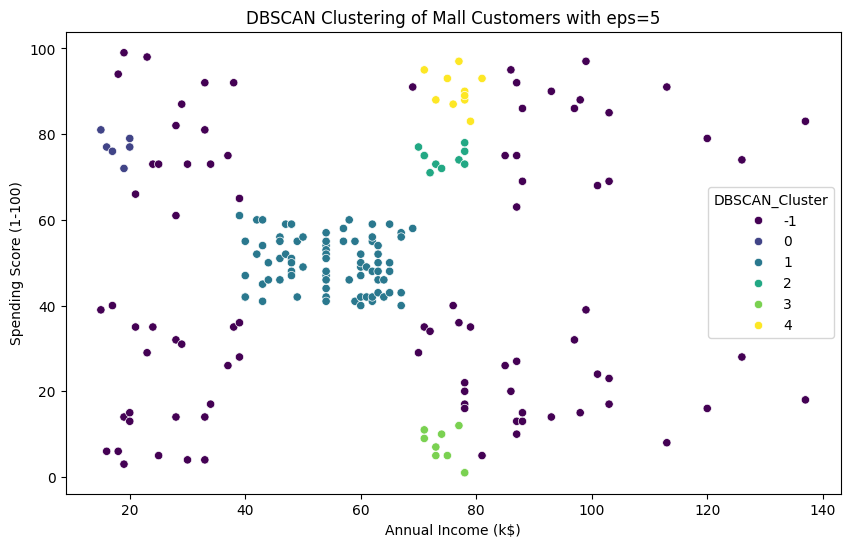

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', palette='viridis', legend='full')
plt.title('DBSCAN Clustering of Mall Customers with eps=5')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [9]:
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   DBSCAN_Cluster  
0              -1  
1              -1  
2              -1  
3              -1  
4              -1  


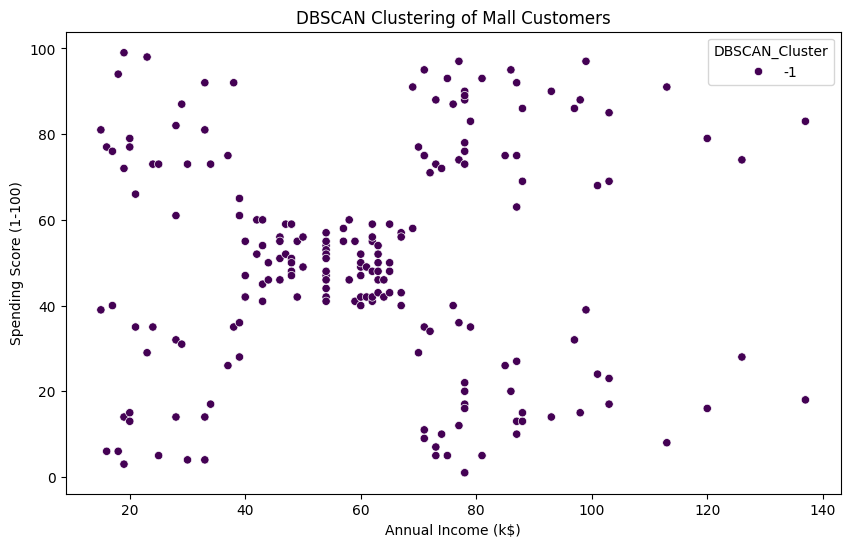

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', palette='viridis', legend='full')
plt.title('DBSCAN Clustering of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()